In [8]:
!pip install tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [2]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [3]:
X = X.reshape(-1, 28, 28, 3) / 255.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [11]:
model = models.Sequential([
    #CNN layers
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
 

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    #ANN layers
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])


In [12]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [13]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=40,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3741 - loss: 2.0393 - val_accuracy: 0.0344 - val_loss: 5.6147 - learning_rate: 3.0000e-04
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.5488 - loss: 1.4415 - val_accuracy: 0.0464 - val_loss: 6.1055 - learning_rate: 3.0000e-04
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.6291 - loss: 1.1665 - val_accuracy: 0.5532 - val_loss: 1.4446 - learning_rate: 3.0000e-04
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.6505 - loss: 1.0311 - val_accuracy: 0.5781 - val_loss: 1.2731 - learning_rate: 3.0000e-04
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6706 - loss: 0.9573 - val_accuracy: 0.6111 - val_loss: 1.1378 - learning_rate: 3.0000e-04
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6861 - loss: 0.9198 - val_accuracy: 0.6500 - val_loss: 0.9677 - learning_rate: 3.0000e-04
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/ste

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Final Training Accuracy:", model_prediction.history['accuracy'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7678 - loss: 0.6488
Test Accuracy: 0.7678482532501221
Test Loss: 0.6487512588500977
Final Training Accuracy: 0.7772091627120972


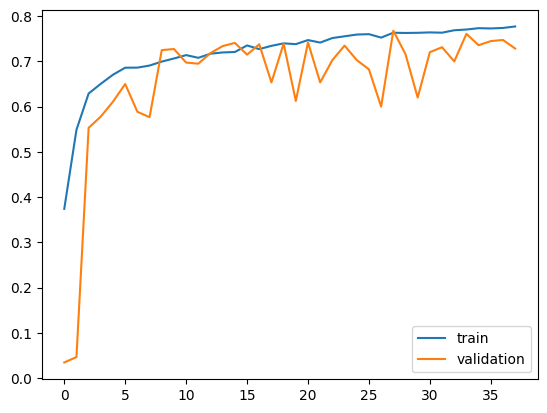

In [15]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Load and preprocess data ---
df = pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X = df.drop('label', axis=1).values
y = df['label'].values

X = X.reshape(-1, 28, 28, 3)
X = X / 255.0

# Resize to 96x96 (MobileNetV2 minimum input)
import tensorflow as tf
X = tf.image.resize(X, (96, 96)).numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Data Augmentation ---
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# --- Load Pretrained Base ---
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))
# Unfreeze the top layers of MobileNetV2 for fine-tuning
base_model.trainable = True

# Let's unfreeze the top 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# --- Build Transfer Learning Model ---
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])


# --- Compile ---
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_transfer_model.keras', monitor='val_loss', save_best_only=True)

# --- Train ---
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# --- Evaluate ---
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)
print("Final Training Accuracy:", history.history['accuracy'][-1])


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.4757 - loss: 1.5364 - val_accuracy: 0.6685 - val_loss: 1.2163
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 173ms/step - accuracy: 0.6447 - loss: 1.1351 - val_accuracy: 0.6685 - val_loss: 1.1426
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.6601 - loss: 1.0540 - val_accuracy: 0.6690 - val_loss: 1.0874
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 188ms/step - accuracy: 0.6696 - loss: 1.0109 - val_accuracy: 0.6715 - val_loss: 1.0398
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.6737 - loss: 0.9667 - val_accuracy: 0.6770 - val_loss: 0.9809
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 187ms/step - accuracy: 0.6822 - loss: 0.9389 - val_accuracy: 0.6800 - val_loss: 0.9420
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 190ms/step - accuracy: 0.6861 - loss: 0.9174 - val_accuracy: 0.6855 - val_loss: 0.8877
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 252ms/step - accuracy: 0.6936 - loss: 0